# Classifiers

In [ ]:
%pip install git+https://github.com/DMJTax/prtools.git

  Cloning https://github.com/DMJTax/prtools.git to /tmp/pip-req-build-wg7ahh9o
  Running command git clone --filter=blob:none --quiet https://github.com/DMJTax/prtools.git /tmp/pip-req-build-wg7ahh9o
  Resolved https://github.com/DMJTax/prtools.git to commit 75d154313ba6a659b0ccd812eb2533929c043927
  Installing build dependencies ...   Resolved https://github.com/DMJTax/prtools.git to commit 75d154313ba6a659b0ccd812eb2533929c043927
  Installing build dependencies ... -done
  Getting requirements to build wheel ... one
  Getting requirements to build wheel ... -done
  Preparing metadata (pyproject.toml) ... one
  Preparing metadata (pyproject.toml) ... -done
done

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import prtools as pr

In [3]:
train_data = pr.gendatd()
test_data = pr.gendatd()

## LDC (Linear Discriminant Classifier)
**How it works:** Finds a linear boundary that best separates classes by maximizing the distance between means and minimizing within-class variance.

**Assumptions:**
- Data from each class is normally distributed (Gaussian)
- All classes share the same covariance matrix

**Ideal use case:**
- Classes are linearly separable or nearly so
- Covariances are similar

**Main formula:**
$$
\delta_k(x) = x^T \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log \pi_k
$$
Where:
- $x$: input vector
- $\mu_k$: mean of class $k$
- $\Sigma$: shared covariance matrix
- $\pi_k$: prior probability of class $k$

**Type:** Generative, parametric, linear classifier

Linear Discriminant Classifier (ldc) test error: 0.1


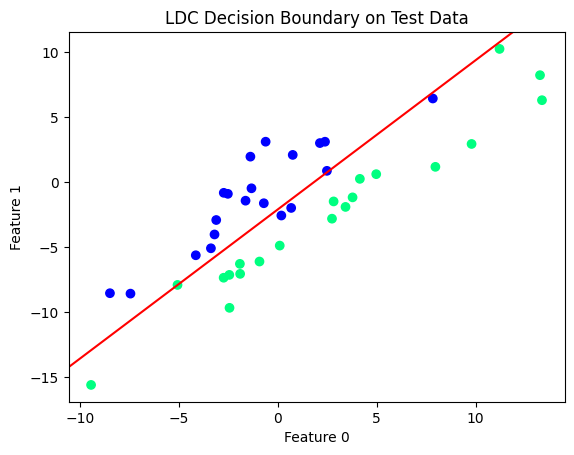

In [4]:
# LDC Example (Linear Discriminant Classifier using prtools)
# Train the ldc classifier on the training set
# Optional parameters for ldc: None
w_ldc = pr.ldc(train_data)

# Evaluate the classifier on the test set
evaluated_test_data_ldc = w_ldc.eval(test_data)

# Compute the classification error on the test set
error_ldc = pr.testc(evaluated_test_data_ldc)

print("Linear Discriminant Classifier (ldc) test error:", error_ldc)

# Visualize the test set and the decision boundary
pr.scatterd(test_data)
pr.plotc(w_ldc)
plt.title('LDC Decision Boundary on Test Data')
plt.show()

## QDC (Quadratic Discriminant Classifier)
**How it works:** Like LDC, but allows each class to have its own covariance matrix, resulting in quadratic decision boundaries.

**Assumptions:**
- Data from each class is normally distributed
- Covariance matrices can differ between classes

**Ideal use case:**
- Classes are not linearly separable
- Covariances differ

**Main formula:**
$$
\delta_k(x) = -\frac{1}{2} \log |\Sigma_k| - \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) + \log \pi_k
$$
Where:
- $\Sigma_k$: covariance matrix of class $k$
- $\mu_k$: mean of class $k$
- $x$: input vector
- $\pi_k$: prior probability of class $k$

**Type:** Generative, parametric, quadratic classifier

Quadratic Discriminant Classifier (qdc) test error: 0.175


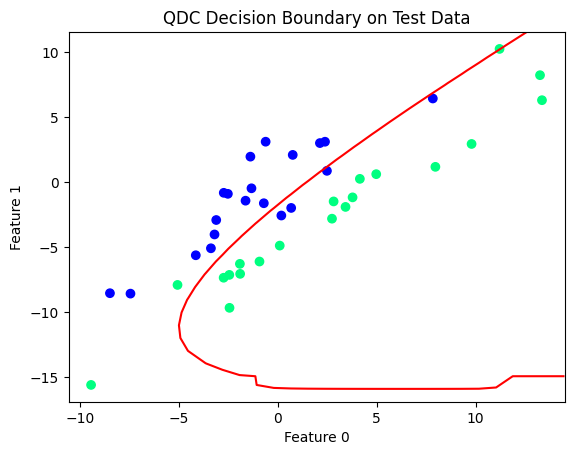

In [5]:
# QDC Example (Quadratic Discriminant Classifier using prtools)
# Train the Quadratic Discriminant Classifier (qdc)
# Optional parameters for qdc: None
w_qdc = pr.qdc(train_data)

# Evaluate the classifier on the test set
evaluated_test_data_qdc = w_qdc.eval(test_data)

# Compute the classification error on the test set
error_qdc = pr.testc(evaluated_test_data_qdc)

print("Quadratic Discriminant Classifier (qdc) test error:", error_qdc)

# Visualize the test set and the decision boundary
pr.scatterd(test_data)
pr.plotc(w_qdc)
plt.title('QDC Decision Boundary on Test Data')
plt.show()

## NNC (Nearest Neighbor Classifier)
**How it works:** Assigns a class to a sample based on the label of its closest training sample (using a distance metric, usually Euclidean).

**Assumptions:**
- No explicit assumptions about data distribution

**Ideal use case:**
- Enough labeled data
- Complex decision boundaries

**Main formula:**
$$
\text{Class}(x) = \text{Class}(\arg\min_{x_i \in \text{train}} \|x - x_i\|)
$$
Where:
- $x$: input vector
- $x_i$: training sample

**Type:** Non-parametric, instance-based, lazy classifier

In [ ]:
# NNC Example (Nearest Neighbor Classifier using prtools)
# Train the Nearest Mean Classifier (nmc)
# Optional parameters for nmc: None
w_nmc = pr.nmc(train_data)

# Evaluate the classifier on the test set
evaluated_test_data_nmc = w_nmc.eval(test_data)

# Compute the classification error on the test set
error_nmc = pr.testc(evaluated_test_data_nmc)

print("Nearest Mean Classifier (nmc) test error:", error_nmc)

# Visualize the test set and the decision boundary
pr.scatterd(test_data)
pr.plotc(w_nmc)
plt.title('NMC Decision Boundary on Test Data')
plt.show()

## Parzen Classifier
**How it works:** Estimates probability density functions for each class using kernel functions (e.g., Gaussian) and classifies based on highest estimated density.

**Assumptions:**
- No strong assumptions; flexible to data shape

**Ideal use case:**
- Non-parametric density estimate
- Data not well-modeled by parametric distributions

**Main formula:**
$$
\hat{p}_k(x) = \frac{1}{n_k h^d} \sum_{i=1}^{n_k} K\left(\frac{x - x_i}{h}\right)
$$
Where:
- $n_k$: number of samples in class $k$
- $h$: bandwidth
- $K$: kernel function
- $d$: dimensionality

**Type:** Non-parametric, generative, density-based classifier

Parzen Classifier (parzenc) test error: 0.25


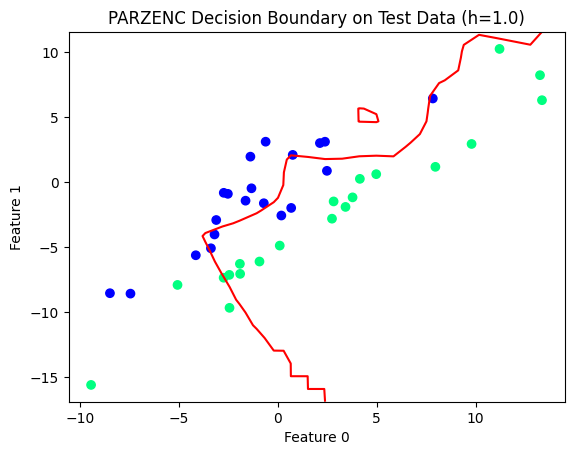

In [9]:
# Parzen Example (Parzen Classifier using prtools)
# Train the Parzen classifier (parzenc)
# Optional parameters for parzenc: h (w in code) (bandwidth, default is estimated)
w_parzenc = pr.parzenc(train_data, w=1.0) # Example with bandwidth h=1.0

# Evaluate the classifier on the test set
evaluated_test_data_parzenc = w_parzenc.eval(test_data)

# Compute the classification error on the test set
error_parzenc = pr.testc(evaluated_test_data_parzenc)

print("Parzen Classifier (parzenc) test error:", error_parzenc)

# Visualize the test set and the decision boundary
pr.scatterd(test_data)
pr.plotc(w_parzenc)
plt.title('PARZENC Decision Boundary on Test Data (h=1.0)')
plt.show()

## KNN (K-Nearest Neighbors)
**How it works:** Assigns a class to a sample based on the majority label among its $K$ nearest neighbors.

**Assumptions:**
- No explicit assumptions about data distribution

**Ideal use case:**
- Enough labeled data
- Complex decision boundaries

**Main formula:**
$$
\text{Class}(x) = \text{mode}\left(\{\text{Class}(x_i) : x_i \in \text{KNN}(x)\}\right)
$$
Where:
- $\text{KNN}(x)$: set of $K$ nearest neighbors of $x$

**Type:** Non-parametric, instance-based, lazy classifier

K-Nearest Neighbors Classifier (knnc) test error: 0.275


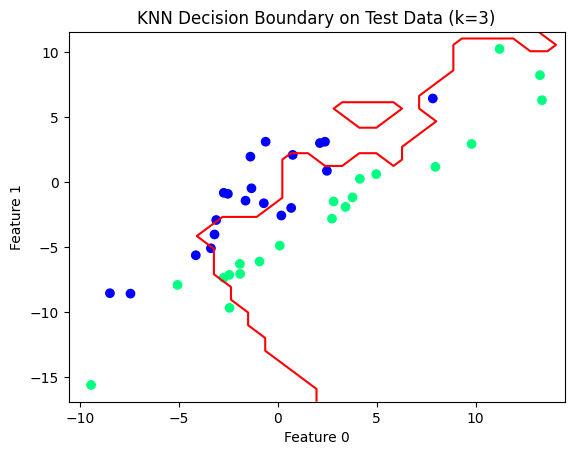

In [10]:
# KNN Example (K-Nearest Neighbors using prtools)
# Train the K-Nearest Neighbors Classifier (knnc)
# Optional parameters for knnc: k (w in code) (number of neighbors, default is 1)
w_knnc = pr.knnc(train_data, w=3) # Example with k=3

# Evaluate the classifier on the test set
evaluated_test_data_knnc = w_knnc.eval(test_data)

# Compute the classification error on the test set
error_knnc = pr.testc(evaluated_test_data_knnc)
print("K-Nearest Neighbors Classifier (knnc) test error:", error_knnc)

# Visualize the test set and the decision boundary
pr.scatterd(test_data)
pr.plotc(w_knnc)
plt.title('KNN Decision Boundary on Test Data (k=3)')
plt.show()
